<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Table of Contents:

- [Imports](#imports)
- [1 - Data Importing and Exploration](#1---data-importing-and-exploration)
    - 1a) Importing
    - 1b) Data Set Dimensions
    - 1c) Missing Values
    - 1d) Categorical Features
    - 1e) Numerical Features
- [2 - Data Preparation](#2---data-preparation)
    - 2a) Dimensionality Zero Handling
    - 2b) Dimensionality Outlier Handling
    - 2c) Duplicate Handling
    - 2d) Revisiting Skew and Correlation
    - 2e) Data Splitting
    - 2f) Misc. Preparations
- [3 - A Simple Model](#3---a-simple-model)
    - 3a) Price Vs. Carat
    - 3b) Findings
    - 3c) LinearRegression Carat Training
    - 3d) LinearRegression Carat Testing
    - 3e) LinearRegression Carat Slope/Intercept
    - 3f) Scatterplot
    - 3g) Discussion
- [4 - Models With More Input Features](#4---models-with-more-input-features)
    - 4a) Ordinal Encoding
    - 4b) One-Hot Encoding
    - 4c) Encoding Comparison

</div>

##### **IMPORTANT**

- The hyperlinks stopped working after walking through question 3, I tried fixing it and it still doesn't work so it may have to do with this being too large of a file to render, my computer limitations, and/or too many potential points of anchorpoints
- The dropdowns may help keep things navigable in-place of the faulty hyperlinks

---

##### **ORIENTATION**

- This follows COMP4432's week 1-2 assignment that is a general overview of the data-science pipeline using seaborn's diamonds dataset and implementing a simple Linear Regressor.

---

##### **SUMMARY**

- Completed

<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Imports

- [Back to Table of Contents](#table-of-contents)

</div>

In [1]:
# Arrays and matricies
import numpy as np

# Databasing
import pandas as pd

# Visualizations
import matplotlib.pyplot as plt
import seaborn as sns

# Data splitting
from sklearn.model_selection import train_test_split

# Linear Regression ML Model
from sklearn.linear_model import LinearRegression

# Metrics
from sklearn.metrics import root_mean_squared_error, mean_absolute_error

# Encoders/Scalers/Transformers
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Ignore warnings because no...
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

Matplotlib is building the font cache; this may take a moment.


<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## 1 - Data Importing and Exploration

- [Back to Table of Contents](#table-of-contents)

</div>

#### **1a) Importing**

In [2]:
# Get the Seaborn Diamonds Dataset
df = sns.load_dataset("diamonds")

# Check if already pandas
print(type(df))

# Print sample
df.head()

<class 'pandas.DataFrame'>


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


---

#### **1b) Data Set Dimensions**

In [4]:
# Cleanly get the shape of the Seaborn diamonds dataset
df_shape = df.shape
rows = df_shape[0]
cols = df_shape[1]

# Print off information WITH COLORS! :D
print('\033[35m'
        'SEABORN DATASET SHAPE'
        f'\n{'='*25}'
        f'\n\033[32mRows:\033[0m\t{rows}'
        f'\n\033[32mCols:\033[0m\t{cols}')

SEABORN DATASET SHAPE
Rows:	53940
Cols:	10


---

#### **1c) Missing Values**

In [5]:
# Get the missing values summary of the diamonds dataset
missing_summary = \
pd.DataFrame({
    "Missing Count" : df.isna().sum(),
    "Missing Percent" : df.isna().mean() * 100
})

# Print off the missing values
missing_summary

,Missing Count,Missing Percent
carat,0,0.0
cut,0,0.0
color,0,0.0
clarity,0,0.0
depth,0,0.0
table,0,0.0
price,0,0.0
x,0,0.0
y,0,0.0
z,0,0.0


---

#### **1d) Categorical Features**

##### 1di) 

In [6]:
# Observe dtypes within the diamonds dataset
df.dtypes

carat       float64
cut        category
color      category
clarity    category
depth       float64
table       float64
price         int64
x           float64
y           float64
z           float64
dtype: object

In [7]:
# Get categorical features
categorical_features = df.columns[df.dtypes == 'category'].to_list()

# Get numerical features
numerical_features = df.columns[df.dtypes != 'category'].to_list()

# Print off distribution
print(f'\033[35mCategorical Features:\033[0m\t{categorical_features}'
      f'\n\033[35mNumerical Features:\033[0m\t{numerical_features}'
    )

Categorical Features:	['cut', 'color', 'clarity']
Numerical Features:	['carat', 'depth', 'table', 'price', 'x', 'y', 'z']


##### 1dii)

In [8]:
# Use panda's describe function for each categorical feature
df[categorical_features].describe()

,cut,color,clarity
count,53940,53940,53940
unique,5,7,8
top,Ideal,G,SI1
freq,21551,11292,13065


##### 1diii)

In [9]:
# Get the unique labels of every categorical feature and save
cut_labels = df['cut'].unique().to_list()
color_labels = df['color'].unique().to_list()
clarity_labels = df['clarity'].unique().to_list()

# Print off results to observe unique labels
print(f'\033[35mCut Labels:\033[0m\t{cut_labels}'
      f'\n\033[35mColor Labels:\033[0m\t{color_labels}'
      f'\n\033[35mClarity Labels:\033[0m\t{clarity_labels}'
     )

Cut Labels:	['Ideal', 'Premium', 'Good', 'Very Good', 'Fair']
Color Labels:	['E', 'I', 'J', 'H', 'F', 'G', 'D']
Clarity Labels:	['SI2', 'SI1', 'VS1', 'VS2', 'VVS2', 'VVS1', 'I1', 'IF']


In [10]:
# Define correct label orders IAW instructions
true_cut_labels = ['Ideal', 'Premium', 'Very Good', 'Good', 'Fair']
true_color_labels = ['D', 'E', 'F', 'G', 'H', 'I', 'J']
true_clarity_labels = ['IF', 'VVS1', 'VVS2', 'VS1', 'VS2', 'SI1', 'SI2', 'I1']

# Verify cut order
if cut_labels == true_cut_labels:
    print(f'\033[32mcut_labels is in the correct order!\033[0m')
else:
    print(f'\033[31mcut_labels is in the wrong order!\033[0m'
          f'\n\tcut_labels:\t{cut_labels}'
          f'\n\ttrue_labels:\t{true_cut_labels}')

# Verify color order
if color_labels == true_color_labels:
    print(f'\033[32mcolor_labels is in the correct order!\033[0m')
else:
    print(f'\033[31mcolor_labels is in the wrong order!\033[0m'
          f'\n\tcolor_labels:\t{color_labels}'
          f'\n\ttrue_labels:\t{true_color_labels}')

# Verify clarity order
if clarity_labels == true_clarity_labels:
    print(f'\033[32mclarity_labels is in the correct order!\033[0m')
else:
    print(f'\033[31mclarity_labels is in the wrong order!\033[0m'
          f'\n\tclarity_labels:\t{clarity_labels}'
          f'\n\ttrue_labels:\t{true_clarity_labels}')


cut_labels is in the wrong order!
	cut_labels:	['Ideal', 'Premium', 'Good', 'Very Good', 'Fair']
	true_labels:	['Ideal', 'Premium', 'Very Good', 'Good', 'Fair']
color_labels is in the wrong order!
	color_labels:	['E', 'I', 'J', 'H', 'F', 'G', 'D']
	true_labels:	['D', 'E', 'F', 'G', 'H', 'I', 'J']
clarity_labels is in the wrong order!
	clarity_labels:	['SI2', 'SI1', 'VS1', 'VS2', 'VVS2', 'VVS1', 'I1', 'IF']
	true_labels:	['IF', 'VVS1', 'VVS2', 'VS1', 'VS2', 'SI1', 'SI2', 'I1']


The above is really just going through the motions, the naming conventions appear consistent so using the "true" version of the labels will be used moving forward with the assignment

##### 1div)

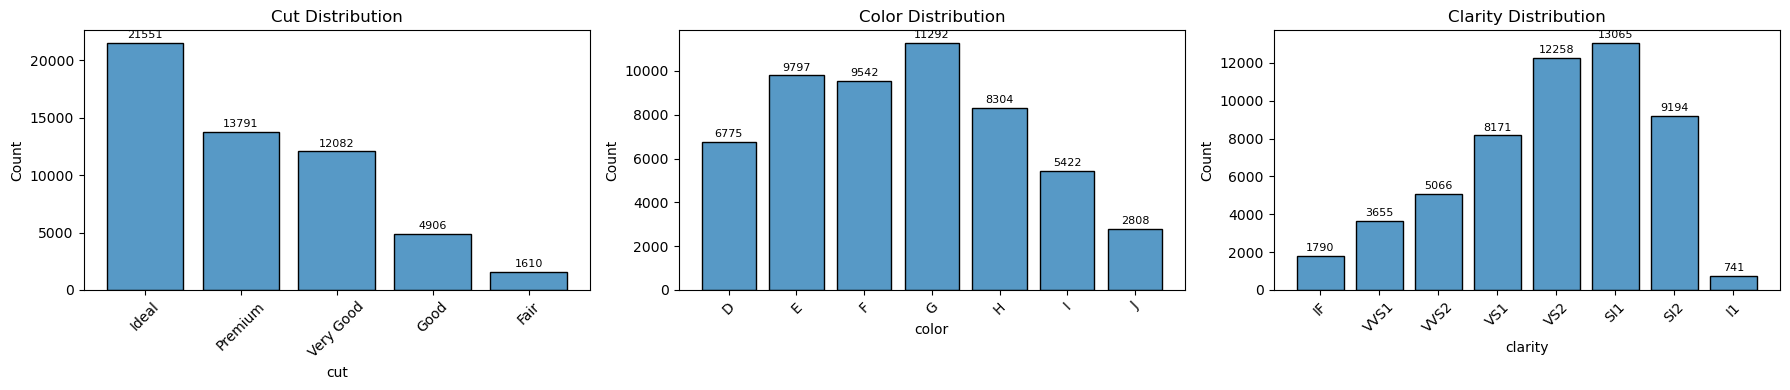

In [11]:
# Tie categorical feature names to proper ordering IAW instructions
order_map = {
    "cut": true_cut_labels,
    "color": true_color_labels,
    "clarity": true_clarity_labels
}

# Set up plots for each categorical feature
fig, axes = plt.subplots(1, len(categorical_features), figsize=(18, 4))
axes = np.atleast_1d(axes)

# Plot distribution of each categorical feature by ordering
for ax, col in zip(axes, categorical_features):
    categories = order_map.get(col, list(df[col].unique()))
    x_vals = pd.Categorical(df[col], categories=categories, ordered=True)

    sns.histplot(
        x=x_vals,
        discrete=True,
        stat="count",
        shrink=0.8,
        ax=ax
    )

    # Add count labels to bars
    for p in ax.patches:
        height = int(p.get_height())
        if height > 0:
            ax.annotate(
                f"{height}",
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center",
                va="bottom",
                fontsize=8,
                xytext=(0, 2),
                textcoords="offset points"
            )

    ax.set_title(f"{col.capitalize()} Distribution")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=45)

# Display visualizations
plt.tight_layout()
plt.show()

##### 1dv)

- **CATEGORICAL FEATURE TAKEAWAY**
    - Cut distribution is positively skewed from best to worst
    - Color distribution is close to no skew from best to worst
    - Clarity distribution is negatively skewed from best to worst
    - More exploration will have to be observed with numerical features, particularly like the price target feature to determine if there is a strong correlation between these categorical features.  In theory, the range of skews are covering a high-quality, mid-quality, and low-quality diamonds and thus may be a strong predictor for a diamond's true price

- **CUT DISTRIBUTION**
    - Skew Type: Positive skew from best to worst
    - Counts:
        - Ideal: 21,551/53,940
        - Premium: 13,791/53,940
        - Very Good: 12,082/53,940
        - Good: 4,906/53,940
        - Fair: 1,610/53,940

- **COLOR DISTRIBUTION**
    - Skew Type: Close to no skew from best to worst
    - Counts:
        - D: 6,775/53,940
        - E: 9,797/53,940
        - F: 9,542/53,940
        - G: 11,292/53,940
        - H: 8,304/53,940
        - I: 5,422/53,940
        - J: 2,808/53,940

- **CLARITY DISTRIBUTION**
    - Skew Type: Negative skew from best to worst
    - Counts:
        - IF: 1,790/53,940
        - VVS1: 3,655/53,940
        - VVS2: 5,066/53,940
        - VS1: 8,171/53,940
        - VS2: 12,258/53,940
        - SI1: 13,065/53,940
        - SI2: 9,194/53,940
        - I1: 741/53,940


---

#### **1e) Numerical Features**

##### 1ei)

In [12]:
# Numerical features obtained earlier
print(f'\033[35mOriginal Numerical Features:\033[0m\t\t{numerical_features}')

# Drop the target 'price' feature
numerical_features.remove('price')
print(f'\033[35mTarget Dropped Numerical Features:\033[0m\t{numerical_features}')

Original Numerical Features:		['carat', 'depth', 'table', 'price', 'x', 'y', 'z']
Target Dropped Numerical Features:	['carat', 'depth', 'table', 'x', 'y', 'z']


##### 1eii)

In [13]:
# Use panda's describe function for each NON-TARGET numerical feature
df[numerical_features].describe()

,carat,depth,table,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,10.740000,58.900000,31.800000


##### 1eiii)

- **INITIAL INSIGHT**
    - 'x','y','z' have zero values where they are intended to denote the respective dimensions of the diamonds.  This likely indicates null fills for dimensions and will need further examination as to whether or not to drop these entries or impute them using groupings of similar diamonds
    - All numerical features are consistent in total entries
    - STD < 1: 'carat', 'z'
    - 1 < STD < 2: 'x', 'y', 'depth'
    - 2 < STD: 'table'
    - Lower STDs may indicate better grouping of distributed entries as opposed to higher distributions which may help for better and more concise predictions.  Mean may be the better generalization for these features
    - For higher STDs, further exploration may help to determine if binning/grouping diamonds provide better insight or if there are things like outliers where statistical methods like Tukey may help reduce the STD

##### 1eiv)

In [14]:
# Get the total zeros for x, y, z
# NOTE: THERE MAY BE OVERLAP OF ZEROS
total_x_zeros = (df['x'] == 0).sum()
total_y_zeros = (df['y'] == 0).sum()
total_z_zeros = (df['z'] == 0).sum()

# Print off counts
print(f'\033[35mTotal "x" Zeros:\033[0m\t{total_x_zeros}')
print(f'\033[35mTotal "y" Zeros:\033[0m\t{total_y_zeros}')
print(f'\033[35mTotal "z" Zeros:\033[0m\t{total_z_zeros}')

Total "x" Zeros:	8
Total "y" Zeros:	7
Total "z" Zeros:	20


##### 1ev)

In [15]:
# Show all entries where 'x' or 'y' or 'z' is zero
df[(df[['x','y','z']] == 0).any(axis=1)]

,carat,cut,color,clarity,depth,table,price,x,y,z
2207,1.00,Premium,G,SI2,59.1,59.0,3142,6.55,6.48,0.0
2314,1.01,Premium,H,I1,58.1,59.0,3167,6.66,6.60,0.0
4791,1.10,Premium,G,SI2,63.0,59.0,3696,6.50,6.47,0.0
5471,1.01,Premium,F,SI2,59.2,58.0,3837,6.50,6.47,0.0
10167,1.50,Good,G,I1,64.0,61.0,4731,7.15,7.04,0.0
11182,1.07,Ideal,F,SI2,61.6,56.0,4954,0.00,6.62,0.0
11963,1.00,Very Good,H,VS2,63.3,53.0,5139,0.00,0.00,0.0
13601,1.15,Ideal,G,VS2,59.2,56.0,5564,6.88,6.83,0.0
15951,1.14,Fair,G,VS1,57.5,67.0,6381,0.00,0.00,0.0
24394,2.18,Premium,H,SI2,59.4,61.0,12631,8.49,8.45,0.0


##### 1evi)

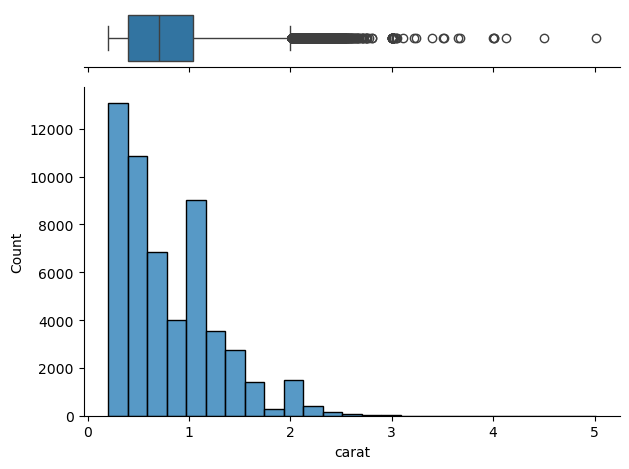

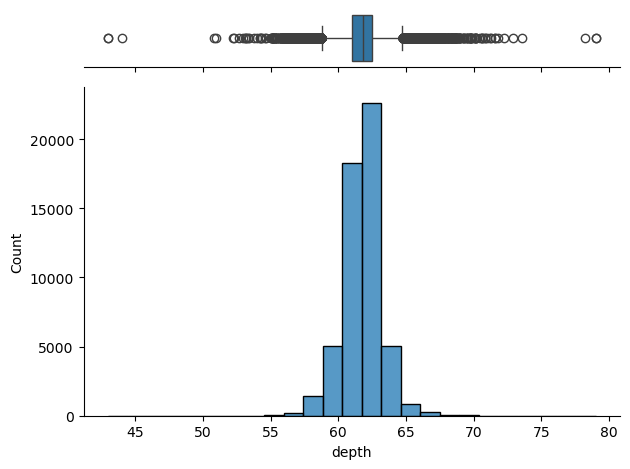

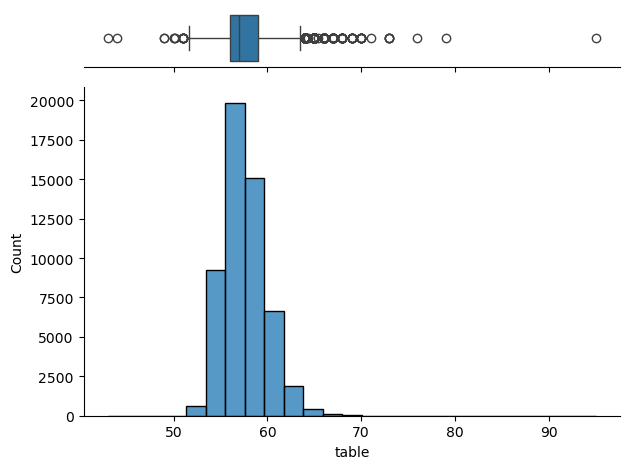

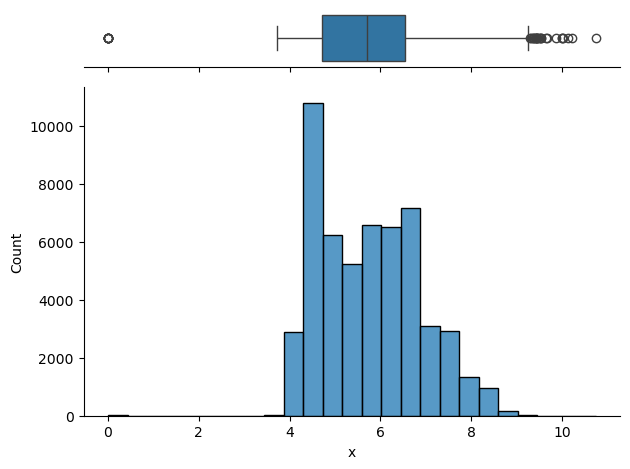

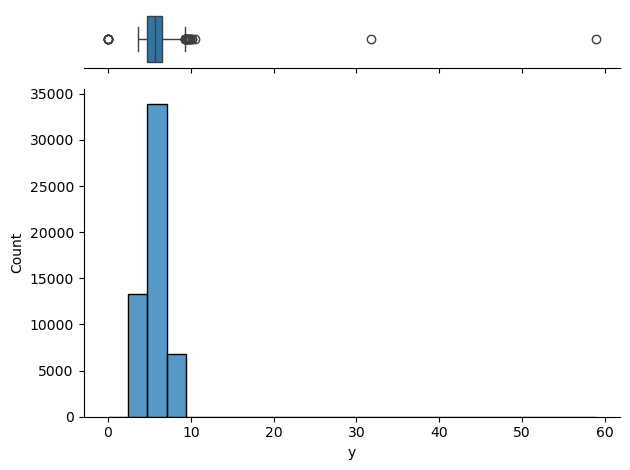

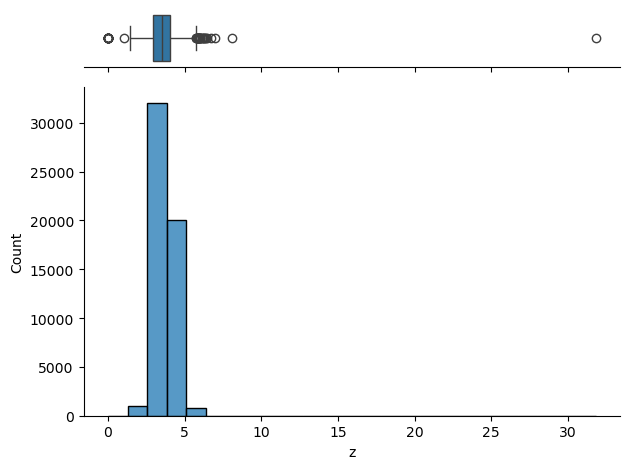

In [16]:
# Use eda.ipynb since the code already exists
for col in numerical_features:
    fig, (ax_box, ax_hist) = plt.subplots(nrows= 2, sharex=True, gridspec_kw={"height_ratios": (.15, .85)})
    sns.boxplot(data= df, x= col, ax= ax_box, orient= 'h')
    sns.histplot(data= df, x= col, ax= ax_hist, bins= 25)
    ax_box.set(yticks=[])
    sns.despine(ax=ax_hist)
    sns.despine(ax=ax_box, left=True)
    plt.tight_layout()

##### 1evii)

In [17]:
# Show the skew value of each NON-TARGET numerical feature
df[numerical_features].skew()

carat    1.116646
depth   -0.082294
table    0.796896
x        0.378676
y        2.434167
z        1.522423
dtype: float64

##### 1eviii)

- **NUMERICAL FEATURE DISTRIBUTION**
    - carat
        - Non-normal distribution
        - Positive skew
        - Potential influence from outliers > 3
    - depth
        - Normal distribution
        - No skew
        - Potential influence from extreme outliers at < 45 and > 77
    - table
        - Close to normal distribution
        - Slight positive skew
        - Potential influence from extreme outliers at > 90 and maybe < 45
    - x
        - Non-normal distribution
        - Slight positive skew
        - Potential influence from zeros
    - y
        - Close to normal distribution
        - No skew
        - Potential influence from zeros and extreme outliers > 30
    - z
        - Close to normal distribution
        - No skew
        - Potential influence from zeros and extreme outliers > 30

##### 1eix)

In [18]:
# Get the correlation dataframe for numerical features
corr = df.corr(numeric_only=True)

# Show only the correlation between the non-target features and target feature
corr[['price']].drop('price').sort_values(by='price', ascending=True)

,price
depth,-0.010647
table,0.127134
z,0.861249
y,0.865421
x,0.884435
carat,0.921591


##### 1ex)

- **UPDATED INSIGHTS**
    - Correlation > 0.86: 'z', 'y', 'x', 'carat'
    - This correlation is in-line with presumably common-knowledge of diamonds where the size and carat of a diamond is a strong predictor of a given diamond's price.  For the dimensions of a diamond, generally more volume equals more cost.  For the quality or carat, generally higher quality means more cost.

##### 1exi)

In [19]:
# Use the same correlation dataframe to observe correlations between other input features
corr.drop('price').T.drop('price')

,carat,depth,table,x,y,z
carat,1.000000,0.028224,0.181618,0.975094,0.951722,0.953387
depth,0.028224,1.000000,-0.295779,-0.025289,-0.029341,0.094924
table,0.181618,-0.295779,1.000000,0.195344,0.183760,0.150929
x,0.975094,-0.025289,0.195344,1.000000,0.974701,0.970772
y,0.951722,-0.029341,0.183760,0.974701,1.000000,0.952006
z,0.953387,0.094924,0.150929,0.970772,0.952006,1.000000


##### 1exii)

- **ABSOLUTE CORRELATION (>0.8)**
    - carat & x
    - carat & y
    - carat & z
    - x & y
    - x & z
    - y & z

##### 1exiii)

- **NUMERICAL FEATURES KEY TAKEAWAYS**
    - Dimensionality and carats have strong correlation with each other and price
    - Removal of outliers and/or zeros/nulls in dimensionality and carat numerical features may improve correlation and learning of the machine learning model
    - Grouping x,y,z into one feature like 'volume' might improve performance and resources required for machine learning (i.e. 1 features is a lot less resource intensive than 3 features and may limit bias of one dimension over another)
    - Additionally, feature engineering a numerical feature denoting the diamond's overall symmetry [0,1] may also help since a symmetrical stone appears more appealing to the eye than a non-symmetrical stone
    - Overall, the above steps may help generalize predictions better

<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## 2 - Data Preparation

- [Back to Table of Contents](#table-of-contents)

</div>

#### **2a) Dimensionality Zero Handling**

##### 2ai)

In [20]:
# Recall that every row with zeros ALWAYS had 'z' as zero
# Thus, keep rows where 'x' and 'y' are not zero
df = df[(df["x"] != 0) & (df["y"] != 0)].reset_index(drop=True)

# Verify the total rows is 53,932
print(df.shape)

# Verify that z still has zeros
df[df['z'] == 0]

(53932, 10)


,carat,cut,color,clarity,depth,table,price,x,y,z
2207,1.00,Premium,G,SI2,59.1,59.0,3142,6.55,6.48,0.0
2314,1.01,Premium,H,I1,58.1,59.0,3167,6.66,6.60,0.0
4791,1.10,Premium,G,SI2,63.0,59.0,3696,6.50,6.47,0.0
5471,1.01,Premium,F,SI2,59.2,58.0,3837,6.50,6.47,0.0
10167,1.50,Good,G,I1,64.0,61.0,4731,7.15,7.04,0.0
13599,1.15,Ideal,G,VS2,59.2,56.0,5564,6.88,6.83,0.0
24391,2.18,Premium,H,SI2,59.4,61.0,12631,8.49,8.45,0.0
26119,2.25,Premium,I,SI1,61.3,58.0,15397,8.52,8.42,0.0
27107,2.20,Premium,H,SI1,61.2,59.0,17265,8.42,8.37,0.0
27497,2.02,Premium,H,VS2,62.7,53.0,18207,8.02,7.95,0.0


##### 2aii)

In [ ]:
# Impute zeros in 'z'
z_imputed = (df["depth"] / 100) * ((df["x"] + df["y"]) / 2)
df["z"] = df["z"].where(df["z"] != 0, z_imputed)

# Verify no zeros in 'z'
print(f'\033[35mTotal Zeros in "z":\033[0m\t{df[df['z'] == 0].shape[0]}')

Total Zeros in "z":	0


##### 2aiii)

In [24]:
# Verify describe matches instructions
df[df.columns[df.dtypes != 'category'].to_list()].describe().T

,count,mean,std,min,25%,50%,75%,max
carat,53932.0,0.797879,0.473986,0.20,0.40,0.70,1.04,5.01
depth,53932.0,61.749336,1.432514,43.00,61.00,61.80,62.50,79.00
table,53932.0,57.457029,2.234064,43.00,56.00,57.00,59.00,95.00
price,53932.0,3932.136079,3988.734835,326.00,949.75,2401.00,5324.00,18823.00
x,53932.0,5.732007,1.119670,3.73,4.71,5.70,6.54,10.74
y,53932.0,5.735254,1.140343,3.68,4.72,5.71,6.54,58.90
z,53932.0,3.540265,0.702667,1.07,2.91,3.53,4.04,31.80


---

#### **2b) Dimensionality Outlier Handling**

##### 2bi)

In [25]:
# Filter to 1 <= x,y,z <= 11
df = df[
(df['x'].between(1,11)) & \
(df['y'].between(1,11)) & \
(df['z'].between(1,11)) \
]

##### 2bii)

In [26]:
# Verify dataframe shape IAW instructions
df.shape[0] == 53929

True

---

#### **2c) Duplicate Handling**

##### 2ci)

In [27]:
# Drop duplicate rows
df = df.drop_duplicates()

##### 2cii)

In [28]:
# Verify dataframe shape IAW instructions
df.shape[0] == 53784

True

---

#### **2d) Revisiting Skew and Correlation**

##### 2di)

In [29]:
# Recalculate skew of NON-TARGET numerical features
df[numerical_features].skew()

carat    1.113733
depth   -0.113829
table    0.791614
x        0.396972
y        0.391432
z        0.391866
dtype: float64

##### 2dii)

In [30]:
# Recalculate correlation dataframe for numerical features
corr = df.corr(numeric_only=True)

# Show only the correlation between the non-target features and the target feature
corr[['price']].drop('price').sort_values(by='price', ascending=True)

,price
depth,-0.011008
table,0.126582
z,0.882001
x,0.887122
y,0.888713
carat,0.921561


##### 2diii)

In [31]:
# Reshow the correlation between NON-TARGET numerical features
corr.drop('price').T.drop('price')

,carat,depth,table,x,y,z
carat,1.000000,0.027948,0.181126,0.977842,0.976924,0.976518
depth,0.027948,1.000000,-0.297570,-0.025227,-0.028343,0.096322
table,0.181126,-0.297570,1.000000,0.195483,0.189301,0.155145
x,0.977842,-0.025227,0.195483,1.000000,0.998654,0.991090
y,0.976924,-0.028343,0.189301,0.998654,1.000000,0.990746
z,0.976518,0.096322,0.155145,0.991090,0.990746,1.000000


##### 2div)

- **NUMERICAL SKEW COMPARISON**
    - 'depth' and 'x' very slightly moved further from 0 skew where all others approached 0 skew to varying extents
    - 'y' and 'z' had the most significant change in skew
- **NUMERICAL CORRELATION COMPARISON**
    - 'depth', 'table', and 'carat' very slightly dropped in correlation where all others increased to varying extents in relation to the target feature
    - 'x', 'y', and 'z' have very similar correlations within 0.88 with a range covering ~0.0067 in relation to the target feature
    - 'carat' and dimensionality correlation all increased slightly
    - dimensionality correlation with other dimensionaliity increased to over ~0.99
- **GENERAL TAKEAWAY**
    - The dimensionality features are improved in skewness and correlation

---

#### **2e) Data Splitting**

In [32]:
# Define the training features and target feature
X = df.drop(columns=['price'])
y = df['price']

# Split into 80% train and 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=411)

In [33]:
# Sanity check of splitting
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(43027, 9)
(43027,)
(10757, 9)
(10757,)


---

#### **2f) Misc. Preparations**

"The categorical features and the scales of the numerical features still need to be addressed. But,
given the large correlation observed between the input feature carat and the target variable price,
a quick and simple model is going to be constructed." - Instructions

- No further preparations will be conducted
- This is handled in "4 - Models With More Input Features"

<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## 3 - A Simple Model

- [Back to Table of Contents](#table-of-contents)

</div>

#### **3a) Price Vs. Carat**

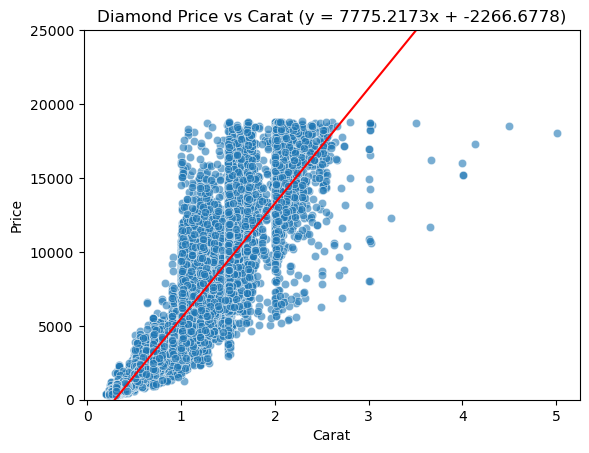

In [71]:
# Setup y vs. x IAW instructions
# NOTE: This will show the best fit in relation to carat
y = y_train.to_numpy()
x = X_train['carat'].to_numpy()

# Get best fit line info
m, b = np.polyfit(x, y, 1)

# Plot with best fit line
sns.scatterplot(x=x, y=y, alpha=0.6)
xx = np.linspace(x.min(), x.max(), 200)
plt.plot(xx, m*xx + b, color="red")
plt.title(f"Diamond Price vs Carat (y = {m:.4f}x + {b:.4f})")
plt.xlabel('Carat')
plt.ylabel('Price')
plt.ylim(0, 25000)
plt.show()

---

#### **3b) Findings**

In [43]:
# Get ranges of x and y
print(f'Price range: [{y_train.min()}, {y_train.max()}]'
      f'\nCarat range: [{X_train['carat'].min()}, {X_train['carat'].max()}]')

Price range: [326, 18823]
Carat range: [0.2, 5.01]


In [44]:
# Observe carats with maximal price
df[df['price'] == df['price'].max()]

,carat,cut,color,clarity,depth,table,price,x,y,z
27743,2.29,Premium,I,VS2,60.8,60.0,18823,8.5,8.47,5.16


In [45]:
# Observe carats with minimal price
df[df['price'] == df['price'].min()]

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31


- **KEY OBSERVATIONS**
    - Price Range: [326, 18,823]
    - Carat Range: [0.2, 5.01]
    - Positive Trend-line (y=0.0001x+0.3676)
    - Carats > 3 appear to be outliers in relation to the price where they can be anywhere from ~7,000-~19,000
    - 0 < Carat < 1: ~[0, 8000]
    - 1 < Carat < 2: ~[1000, 19000]
    - 2 < Carat < 3: ~[5000, 19000]
    - 3 < Carat < 4: ~[8000, 19000]
    - 4 < Carat < 5: ~[15000, 19000]
    - 5 < Carat: ~17500
    - Maximal price at 2.29 carats
    - Minimal price at 0.23 and 0.21 carats

---

#### **3c) LinearRegression Carat Training**

In [46]:
# Define a simple linear regression model
lr_simple = LinearRegression()

# Fit ONLY on carat
lr_simple.fit(X_train[['carat']], y_train)

LinearRegression()

---

#### **3d) LinearRegression Carat Testing**

In [47]:
# Make predictions on the test set
preds = lr_simple.predict(X_test[['carat']])

# Get the RMSE and MAE
rmse = root_mean_squared_error(y_test, preds)
mae = mean_absolute_error(y_test, preds)

# Print results
print(f'\033[35mRMSE:\033[0m\t{rmse:.2f}')
print(f'\033[35mMAE:\033[0m\t{mae:.2f}')

RMSE:	1557.74
MAE:	1015.10


---

#### **3e) LinearRegression Carat Slope/Intercept**

In [48]:
# Get slope/intercept
m = lr_simple.coef_[0]
b = lr_simple.intercept_

# Print results
print(f'\033[35mSlope:\033[0m\t\t{m:.2f}')
print(f'\033[35mIntercept:\033[0m\t{b:.2f}')

Slope:		7775.22
Intercept:	-2266.68


---

#### **3f) Scatterplot**

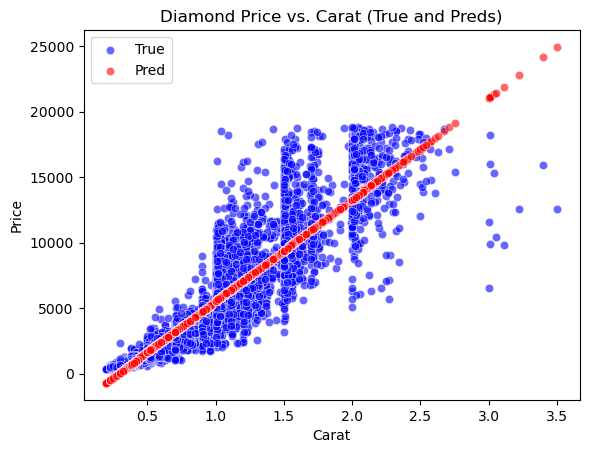

In [72]:
# Setup y vs. x
y_true = y_test.to_numpy()
y_pred = preds
x = X_test['carat'].to_numpy()

# Plot
sns.scatterplot(x=x, y=y_true, alpha=0.6, color='blue', label='True')
sns.scatterplot(x=x, y=y_pred, alpha=0.6, color='red', label='Pred')
plt.title('Diamond Price vs. Carat (True and Preds)')
plt.xlabel('Carat')
plt.ylabel('Price')
plt.legend()
plt.show()

---

#### **3g) Discussion**

- **KEY FINDINGS**
    - Given that a linear regression model will learn the data to create a best fit line of the data, this best fit appears to be in-line with what one may draw visually
    - The large variance and lack of clustering seen with carats > 2.5 and pricing may be the cause for pulling the line in a steeper fashion
    - Most price points appear to cover more than 1 carat throughout which may explain the relatively high RMSE of the model
    - Note that the best fit line intercept is a negative value even though the minimum price of the true dataset's prices are 326.  Not only does this not make logical sense, but also means that this model's best fit line is guaranteed to be incorrect with any diamond whose carat is less than ~0.29 as it will return a negative price value
    - Besides the non-sensical intercept of the best fit line, the assumption is that for every one carat increase, the diamond's worth is generally ~7,775 more
    - In general, this model reinforces an otherwise common sense notion the heavier a diamond is, then the more it will be worth.  But outside of this, there's not much to be garnered from this model

<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## 4 - Models With More Input Features

- [Back to Table of Contents](#table-of-contents)

</div>

#### **4a) Ordinal Encoding**

##### 4ai)

In [55]:
# Verify order of categorical features seen
X_train.dtypes

carat       float64
cut        category
color      category
clarity    category
depth       float64
table       float64
x           float64
y           float64
z           float64
dtype: object

In [56]:
list(reversed(true_cut_labels))

['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']

In [57]:
# Ensure ordinal encoder follows the same ranking schema defined earlier
# Define ordering IAW dataframe precedence
# NOTE: Encoding starts with 0 which should denote the worst, so orders will be flipped
cat_order = [
    list(reversed(true_cut_labels)),
    list(reversed(true_color_labels)),
    list(reversed(true_clarity_labels))
]

# Create nuanced OrdinalEncoder
ranked_ordenc = OrdinalEncoder(
    categories=cat_order,
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

In [58]:
# Use ColumnTransformer to transform categorical with OrdinalEncoder and numerical with StandardScaler
column_transformer_ordenc = ColumnTransformer(transformers=[
                                                    ("cat_transform", ranked_ordenc, categorical_features), 
                                                    ("num_transform", StandardScaler(), numerical_features)],
                                        remainder='passthrough',
                                        verbose_feature_names_out=False)

# Fit and transform training dataframe
column_transformer_ordenc.fit(X=X_train)
X_train_ordenc = column_transformer_ordenc.transform(X=X_train)
feature_names = column_transformer_ordenc.get_feature_names_out()
X_train_ordenc = pd.DataFrame(X_train_ordenc, columns=feature_names, index=X_train.index)

# Fit and transform testing dataframe
column_transformer_ordenc.fit(X=X_test)
X_test_ordenc = column_transformer_ordenc.transform(X=X_test)
feature_names = column_transformer_ordenc.get_feature_names_out()
X_test_ordenc = pd.DataFrame(X_test_ordenc, columns=feature_names, index=X_test.index)

# Observe transformed dataframe
X_train_ordenc.head()

,cut,color,clarity,carat,depth,table,x,y,z
19802,3.0,0.0,4.0,1.503640,0.239567,0.247535,1.454460,1.499107,1.503511
40918,4.0,4.0,2.0,-1.054256,0.169902,-1.048338,-1.292802,-1.276900,-1.262365
38301,1.0,3.0,1.0,-0.906279,1.075547,-1.093023,-1.033289,-1.015523,-0.914820
28317,2.0,3.0,4.0,-0.990837,0.169902,0.694388,-1.230161,-1.186770,-1.189960
32624,1.0,5.0,6.0,-1.202233,-0.805409,3.375504,-1.597059,-1.592356,-1.653353


##### 4aii)

In [59]:
# Verify describe matches instructions
X_train_ordenc.describe().T

,count,mean,std,min,25%,50%,75%,max
cut,43027.0,2.901109e+00,1.120502,0.000000,2.000000,3.000000,4.000000,4.000000
color,43027.0,3.405397e+00,1.699922,0.000000,2.000000,3.000000,5.000000,6.000000
clarity,43027.0,3.057685e+00,1.648355,0.000000,2.000000,3.000000,4.000000,7.000000
carat,43027.0,2.546440e-16,1.000012,-1.265652,-0.842860,-0.208671,0.510077,8.902512
depth,43027.0,-6.341330e-16,1.000012,-13.066456,-0.526748,0.030572,0.518227,12.012959
table,43027.0,4.942770e-15,1.000012,-6.455256,-0.646170,-0.199318,0.694388,16.781085
x,43027.0,-2.985710e-16,1.000012,-1.793931,-0.908006,-0.031030,0.720664,4.479133
y,43027.0,-2.744607e-16,1.000012,-1.826694,-0.907367,-0.024092,0.723988,4.329193
z,43027.0,-7.523724e-16,1.000012,-3.579329,-0.900339,-0.016997,0.721536,4.978958


##### 4aiii)

In [60]:
# Define a simple linear regression model for ordenc
lr_simple_ordenc = LinearRegression()

# Fit on all feature data???
# I'm unsure as to what specifically you want us training on
lr_simple_ordenc.fit(X_train_ordenc, y_train)

LinearRegression()

##### 4aiv)

In [61]:
# Make predictions on the test set
preds_ordenc = lr_simple_ordenc.predict(X_test_ordenc)

# Get the RMSE and MAE
rmse_ordenc = root_mean_squared_error(y_test, preds_ordenc)
mae_ordenc = mean_absolute_error(y_test, preds_ordenc)

# Print results
print(f'\033[35mRMSE:\033[0m\t{rmse_ordenc:.2f}')
print(f'\033[35mMAE:\033[0m\t{mae_ordenc:.2f}')

RMSE:	1225.63
MAE:	813.68


##### 4av)

In [62]:
# Get coefficients and intercept
ordenc_coef = [float(coef.round(2)) for coef in lr_simple_ordenc.coef_]
ordenc_intcpt = lr_simple_ordenc.intercept_

# Create coefficient table
coef_table_ordenc = pd.DataFrame({"feature":feature_names, "coef":ordenc_coef})

# Print results
print(f'\033[35mIntercept:\033[0m\t{ordenc_intcpt:.2f}')
coef_table_ordenc

Intercept:	954.33


,feature,coef
0,cut,129.95
1,color,323.76
2,clarity,493.71
3,carat,5210.84
4,depth,72.16
5,table,-44.42
6,x,-2116.81
7,y,2536.58
8,z,-1504.05


##### 4avi)

- **KEY OBSERVATIONS**
    - Categorical coefficients make logical sense since the encoding method matched the given quality ranking to the respective value where 0 is the worst quality.  In other words, as cut, color, or clarity quality increases, then so does the price of the diamond
    - carat and depth coefficients also make logical sense
    - x,y,z coefficients don't make logical sense and surprisingly shows y as the significantly more determining factor as opposed to x and z in relation to a diamond's price
    - From the coefficient table, it may be beneficial to make a model that looks at carat, y, clarity, color, and cut and observe if performance becomes better or not.  Alternatively, if the performance drop-off isn't significant, then this model would be more beneficial for saving resources and generalizability.

---

#### **4b) One-Hot Encoding**

##### 4bi)

In [63]:
# Reuse the worst-to-best categorical ordering
cat_order

[['Fair', 'Good', 'Very Good', 'Premium', 'Ideal'],
 ['J', 'I', 'H', 'G', 'F', 'E', 'D'],
 ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']]

In [64]:
# Create the correctly ordered OneHotEncoder
ranked_onehot = OneHotEncoder(
    categories=cat_order,
    sparse_output=False,
    drop='first'
)

In [65]:
# Use ColumnTransformer to transform categorical with OneHotEncoder and numerical with StandardScaler
column_transformer_onehot = ColumnTransformer(transformers=[
    ("cat_transform", ranked_onehot, categorical_features),
    ("num_transform", StandardScaler(), numerical_features)],
    remainder="passthrough",
    verbose_feature_names_out=False)

# Fit and transform training dataframe
column_transformer_onehot.fit(X=X_train)
X_train_onehot = column_transformer_onehot.transform(X=X_train)
feature_names = column_transformer_onehot.get_feature_names_out()
X_train_onehot = pd.DataFrame(X_train_onehot, columns=feature_names, index=X_train.index)

# Fit and transform testing dataframe
column_transformer_onehot.fit(X=X_test)
X_test_onehot = column_transformer_onehot.transform(X=X_test)
feature_names = column_transformer_onehot.get_feature_names_out()
X_test_onehot = pd.DataFrame(X_test_onehot, columns=feature_names, index=X_test.index)

# Observe transformed dataframe
X_train_onehot.head()

,cut_Good,cut_Very Good,cut_Premium,cut_Ideal,color_I,color_H,color_G,color_F,color_E,color_D,...,clarity_VS1,clarity_VVS2,clarity_VVS1,clarity_IF,carat,depth,table,x,y,z
19802,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.503640,0.239567,0.247535,1.454460,1.499107,1.503511
40918,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,-1.054256,0.169902,-1.048338,-1.292802,-1.276900,-1.262365
38301,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,-0.906279,1.075547,-1.093023,-1.033289,-1.015523,-0.914820
28317,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,-0.990837,0.169902,0.694388,-1.230161,-1.186770,-1.189960
32624,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,-1.202233,-0.805409,3.375504,-1.597059,-1.592356,-1.653353


##### 4bii)

In [66]:
# Verify consistency IAW instructions using pd.describe()
X_train_onehot.describe().T

,count,mean,std,min,25%,50%,75%,max
cut_Good,43027.0,9.115207e-02,0.287829,0.000000,0.000000,0.000000,0.000000,1.000000
cut_Very Good,43027.0,2.246961e-01,0.417387,0.000000,0.000000,0.000000,0.000000,1.000000
cut_Premium,43027.0,2.534223e-01,0.434976,0.000000,0.000000,0.000000,1.000000,1.000000
cut_Ideal,43027.0,4.000744e-01,0.489919,0.000000,0.000000,0.000000,1.000000,1.000000
color_I,43027.0,1.006345e-01,0.300848,0.000000,0.000000,0.000000,0.000000,1.000000
color_H,43027.0,1.540893e-01,0.361039,0.000000,0.000000,0.000000,0.000000,1.000000
color_G,43027.0,2.089153e-01,0.406539,0.000000,0.000000,0.000000,0.000000,1.000000
color_F,43027.0,1.777721e-01,0.382325,0.000000,0.000000,0.000000,0.000000,1.000000
color_E,43027.0,1.815372e-01,0.385467,0.000000,0.000000,0.000000,0.000000,1.000000
color_D,43027.0,1.251772e-01,0.330924,0.000000,0.000000,0.000000,0.000000,1.000000


##### 4biii)

In [67]:
# Define a simple linear regression model for onehotencoder
lr_simple_onehot = LinearRegression()

# Running with the assumption of fitting on all available feature data
# i.e. all NON-TARGET features
lr_simple_onehot.fit(X_train_onehot, y_train)

LinearRegression()

##### 4biv)

In [68]:
# Make predictions on the test set
preds_onehot = lr_simple_onehot.predict(X_test_onehot)

# Get the RMSE and MAE
rmse_onehot = root_mean_squared_error(y_test, preds_onehot)
mae_onehot = mean_absolute_error(y_test, preds_onehot)

# Print results
print(f'\033[35mRMSE:\033[0m\t{rmse_onehot:.2f}')
print(f'\033[35mMAE:\033[0m\t{mae_onehot:.2f}')

RMSE:	1135.93
MAE:	745.35


##### 4bv)

In [69]:
# Get coefficients and intercept
onehot_coef = [float(coef.round(2)) for coef in lr_simple_onehot.coef_]
onehot_intcpt = lr_simple_onehot.intercept_

# Create coefficient table
coef_table_onehot = pd.DataFrame({"feature":feature_names, "coef":onehot_coef})

# Print results
print(f'\033[35mIntercept:\033[0m\t{onehot_intcpt:.2f}')
coef_table_onehot

Intercept:	-2477.34


,feature,coef
0,cut_Good,507.93
1,cut_Very Good,640.78
2,cut_Premium,731.51
3,cut_Ideal,772.13
4,color_I,904.45
5,color_H,1404.02
6,color_G,1898.75
7,color_F,2116.28
8,color_E,2170.22
9,color_D,2380.27


##### 4bvi)

- **KEY OBSERVATIONS**
    - Similar to the ordinal encoding, because of the strict manner of ordering the encoded categorical values from worst to best in tandem with numerical least to greatest, the output coefficients - yet again - demonstrate the logical expectation that as quality of a diamond increases, then so does the price
    - Largest to note, there is a distinct coefficient with every quality level in their respective category and you can observe that the very best quality in each category is contributing the most increase in price within all of their counterparts in said category
    - In summary, carat persists to be the best contributor to price, but now there are distinct and presumably best-fit slopes for how much each distinct sub-category contributes to the diamond's overall price

---

#### **4c) Encoding Comparison**

##### 4ci)

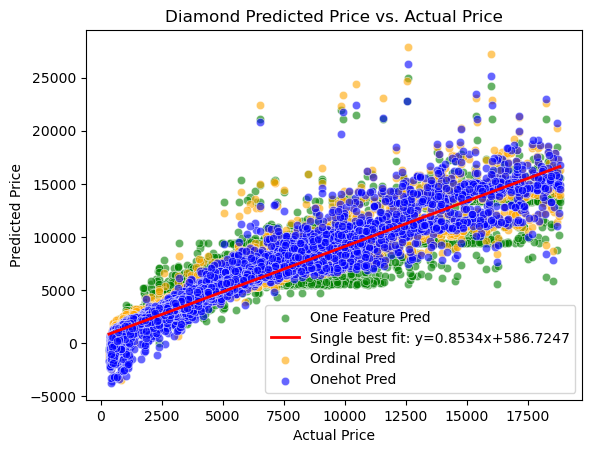

In [74]:
# Setup y vs. x
x_true = y_test.to_numpy()
y_pred = preds

# Plot true data
sns.scatterplot(x=x_true, y=y_pred, alpha=0.6, color="green", label="One Feature Pred")

# Best-fit line for true data (y vs x)
m, b = np.polyfit(x_true, y_pred, 1)
xx = np.linspace(x_true.min(), x_true.max(), 200)
plt.plot(xx, m*xx + b, color="red", linewidth=2, label=f"Single best fit: y={m:.4f}x+{b:.4f}")

# Plot 3 model prediction data (Is noisy, but strictly following instructions)
# Please see below block for a cleaner visual that is more meaningful for comparison's sake
sns.scatterplot(x=x_true, y=preds_ordenc, alpha=0.6, color='orange', label='Ordinal Pred')
sns.scatterplot(x=x_true, y=preds_onehot, alpha=0.6, color='blue', label='Onehot Pred')

plt.title("Diamond Predicted Price vs. Actual Price")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.legend()
plt.show()


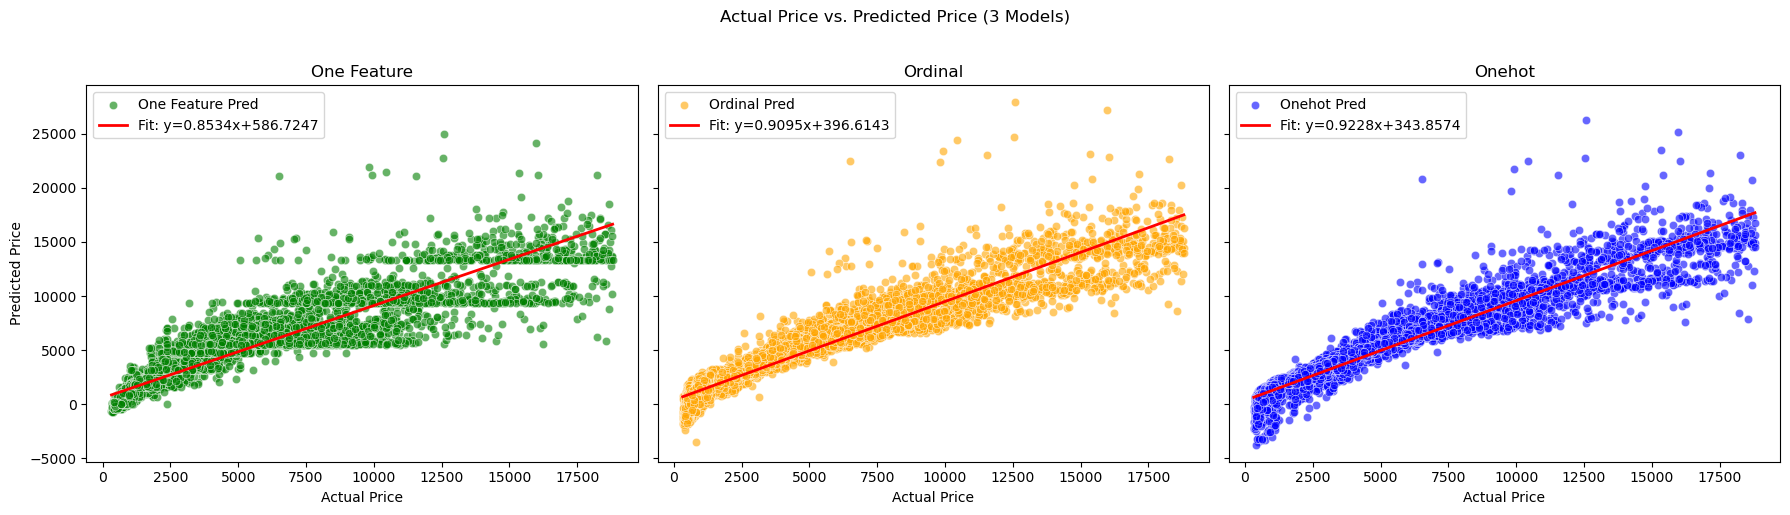

In [75]:
# Setup y vs. x
x_true = y_test.to_numpy()
y_pred_onefeature = preds
y_pred_ordinal = preds_ordenc
y_pred_onehot = preds_onehot

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

# --- One Feature ---
sns.scatterplot(ax=axes[0], x=x_true, y=y_pred_onefeature, alpha=0.6, color="green", label="One Feature Pred")
m, b = np.polyfit(x_true, y_pred_onefeature, 1)
xx = np.linspace(x_true.min(), x_true.max(), 200)
axes[0].plot(xx, m*xx + b, color="red", linewidth=2, label=f"Fit: y={m:.4f}x+{b:.4f}")
axes[0].set_title("One Feature")
axes[0].set_xlabel("Actual Price")
axes[0].set_ylabel("Predicted Price")
axes[0].legend()

# --- Ordinal ---
sns.scatterplot(ax=axes[1], x=x_true, y=y_pred_ordinal, alpha=0.6, color="orange", label="Ordinal Pred")
m, b = np.polyfit(x_true, y_pred_ordinal, 1)
xx = np.linspace(x_true.min(), x_true.max(), 200)
axes[1].plot(xx, m*xx + b, color="red", linewidth=2, label=f"Fit: y={m:.4f}x+{b:.4f}")
axes[1].set_title("Ordinal")
axes[1].set_xlabel("Actual Price")
axes[1].set_ylabel("Predicted Price")
axes[1].legend()

# --- Onehot ---
sns.scatterplot(ax=axes[2], x=x_true, y=y_pred_onehot, alpha=0.6, color="blue", label="Onehot Pred")
m, b = np.polyfit(x_true, y_pred_onehot, 1)
xx = np.linspace(x_true.min(), x_true.max(), 200)
axes[2].plot(xx, m*xx + b, color="red", linewidth=2, label=f"Fit: y={m:.4f}x+{b:.4f}")
axes[2].set_title("Onehot")
axes[2].set_xlabel("Actual Price")
axes[2].set_ylabel("Predicted Price")
axes[2].legend()

plt.suptitle("Actual Price vs. Predicted Price (3 Models)", y=1.02)
plt.tight_layout()
plt.show()


##### 4cii)

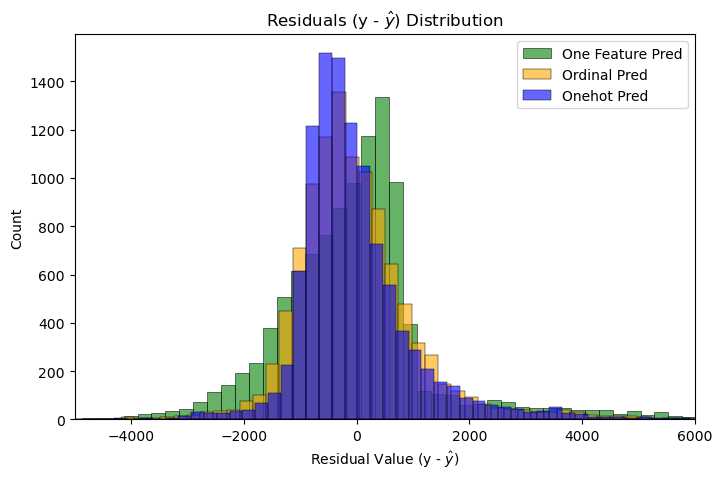

In [76]:
# Setup y vs. x
x_true = y_test.to_numpy()
y_pred = preds

# Residuals
res_onefeature = x_true - preds
res_ordinal = x_true - preds_ordenc
res_onehot = x_true - preds_onehot

# Plot histogram of residuals (Again, this is noisy so see below)
plt.figure(figsize=(8,5))

sns.histplot(res_onefeature, bins=110, alpha=0.6, color="green", label="One Feature Pred")
sns.histplot(res_ordinal, bins=110, alpha=0.6, color="orange", label="Ordinal Pred")
sns.histplot(res_onehot, bins=110, alpha=0.6, color="blue", label="Onehot Pred")

plt.title("Residuals (y - $\\hat{y}$) Distribution")
plt.xlabel("Residual Value (y - $\\hat{y}$)")
plt.ylabel("Count")
plt.xlim(-5000, 6000)
plt.legend()
plt.show()


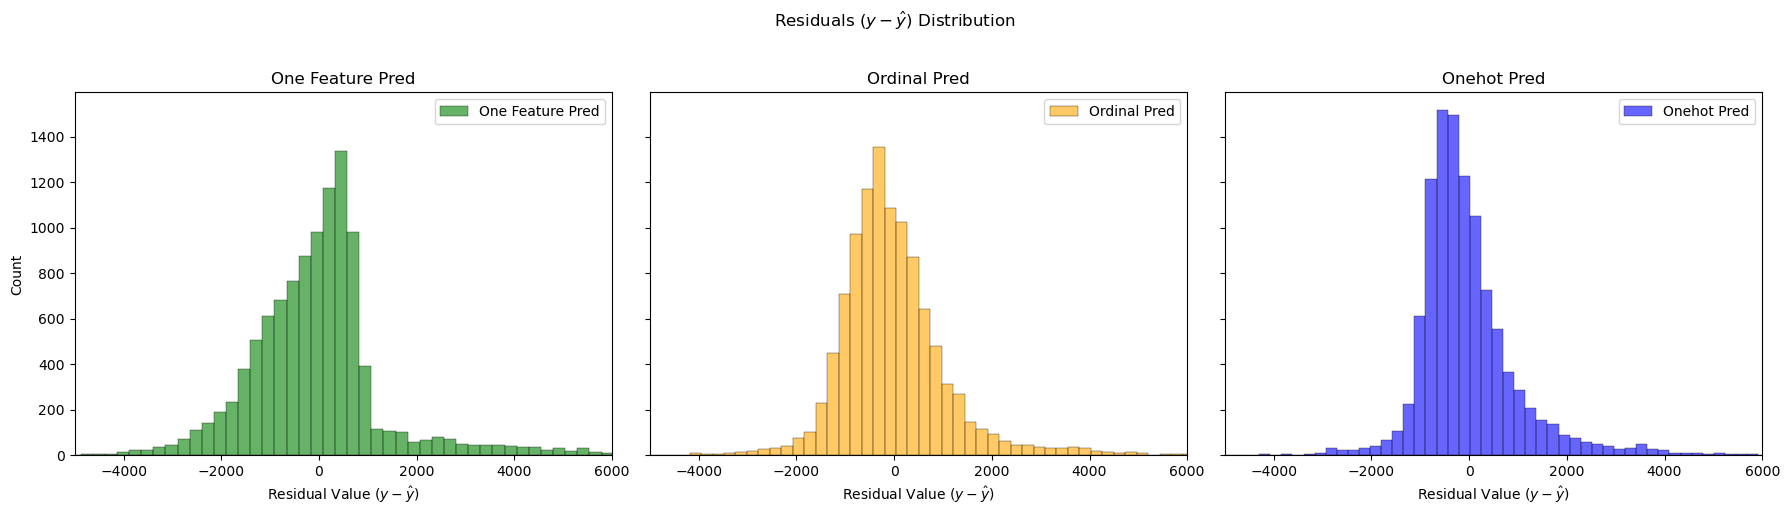

In [77]:
# Setup y vs. x
x_true = y_test.to_numpy()

# Residuals
res_onefeature = x_true - preds
res_ordinal = x_true - preds_ordenc
res_onehot = x_true - preds_onehot

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

sns.histplot(res_onefeature, bins=110, alpha=0.6, color="green", ax=axes[0], label="One Feature Pred")
axes[0].set_title("One Feature Pred")
axes[0].set_xlabel("Residual Value ($y-\\hat{y}$)")
axes[0].set_ylabel("Count")
axes[0].set_xlim(-5000, 6000)

sns.histplot(res_ordinal, bins=110, alpha=0.6, color="orange", ax=axes[1], label="Ordinal Pred")
axes[1].set_title("Ordinal Pred")
axes[1].set_xlabel("Residual Value ($y-\\hat{y}$)")
axes[1].set_ylabel("")
axes[1].set_xlim(-5000, 6000)

sns.histplot(res_onehot, bins=110, alpha=0.6, color="blue", ax=axes[2], label="Onehot Pred")
axes[2].set_title("Onehot Pred")
axes[2].set_xlabel("Residual Value ($y-\\hat{y}$)")
axes[2].set_ylabel("")
axes[2].set_xlim(-5000, 6000)

for ax in axes:
    ax.legend()

plt.suptitle("Residuals ($y-\\hat{y}$) Distribution", y=1.02)
plt.tight_layout()
plt.show()


##### 4ciii)

- **KEY OBSERVATIONS**
    - Key Summary
        - One Feature Model
            - Very low resource requirements for scalability (Just needs one feature)
            - Visually appeared to have the lowest clustering in the scatterplot and the worst skewness in residual distribution (Positive skew)
            - Really not much insight can be garnered from this model
        - Ordinal Encoded Model
            - Would require more, but not the most resources for scalability (Particularly because all NON-TARGET features were fed through it and required data transformation)
            - Visually appeared to have almost the best clustering in the scatterplot and had a seemingly very normal distribution in its residual distribution visualization
            - Much insight can be garnered in reinforcement of general common sense notions of higher quality leads to higher prices
        - OneHot Encoded Model
            - Would require the most resources for scalability (Particularly because of the extreme distinction across all categorical features and required data transformation)
            - Visually appeared to have the best clustering in the scatterplot and a normal distribution similar to the Ordinal Encoded one, but with a much higher count in the center.  Additionally, the best fit-line was the closest to 0 for the intercept and closer to 1 for the slope between all 3 models
            - Most insight can be garnered from this model particularly when observing the unique coefficients for each sub-categorical category of a diamond which further reinforces otherwise common sense notions of higher quality leading to a higher price, but in a much more distilled and specific manner
    - Training Methodology
        - One Feature Model
            - Only trained on seemingly the most important feature, carat
            - The simpliest possible model, but may leave things to be desired from its performance
        - Ordinal Encoded Model
            - Trained on all NON-TARGET features with categorical features encoded ordinally with respect to each categories' worst to best order
            - Ordinal encoding gives categorical features unique numerical values to be interpretted by the machine learning algorithm within the same feature
            - In other words, "cut" has 5 unique labels, these 5 unique labels are now 5 unique integers within "cut"
            - In theory, gives less distinction between unique sub-categories (i.e A diamond's cut quality being "Fair" vs. "Ideal"), but trades less resources for more interpretability
        - OneHot Encoded Model
            - Trained on all NON-TARGET features with categorical features encoded with onehot with respect to each categories' worst to best order
            - OneHot encoding gives categorical features unique T/F integer values for every unique sub-category within them to be interpretted by the machine learning algorithm
            - In other words, "cut" has 5 unique labels, these 5 unique labels become *UNIQUE* features with 0s and 1s to denote if a entry is or is not a specific sub-category.  So now instead of one single feature for "cut", you have 5 features of specific "cut" sub-categories
            - In theory, gives more distinction between unique sub-categories (i.e. A diamond's cut quality being "Fair" vs. "Ideal"), but trades more resources for presumably the best distinction across all sub-categories
    - Interpretability
        - One Feature Model
            - Very straightforward and easy to grasp.  Since the only thing it trained off of is the diamond's carat, we can clearly see how the predictions depend on the diamond's carat
        - Ordinal Encoded Model
            - Much more confusing since everything was passed into it, however, observing the coefficients of respective features - particularly the categorical ones - reinforce an otherwise common sense notion of a better quality diamond will lead to a higher price.  However, if one wants to know clearly at what point the diamond's quality drastically influences price, assuming one exists, then it would be difficult to know.
        - OneHot Encoded Model
            - Similar to the ordinal encoded model, since everything was passed into it, it becomes much harder to interpret.  Alternatively, because there are so many moving parts so to speak, it will take longer to explain why the predictions are the way that they are.  Though, because there are very clear coefficients for every sub-category for the categorical features in the correct logical order, there is a very clear distinction of what specific quality of a diamond contributes how much to the price.  Thus, if more time is allowed for an individual to observe this model, much more may be learned from it as opposed to the other two models